In [1]:
import os
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
import torch
import torch.nn as nn
import torchvision
from torchvision.transforms import v2
from torchvision import models
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torchvision.transforms.functional import to_pil_image
from torchmetrics import MeanMetric, Accuracy
from torchmetrics import ConfusionMatrix, Accuracy, Precision, Recall, F1Score

In [2]:
device = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.mps.is_available()
    else "cpu"
)

print("Device:", device)

seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

Device: cuda


In [3]:
DATA_DIR = "/kaggle/input/datasets/daphn3/dfuc2021/DFU"

train_csv = os.path.join(
    DATA_DIR,
    "DFUC2021_train",
    "train.csv"
)

train_image_dir = os.path.join(
    DATA_DIR,
    "DFUC2021_train",
    "images"
)

test_image_dir = os.path.join(
    DATA_DIR,
    "DFUC2021_test"
)

print("Train CSV:", os.path.exists(train_csv))
print("Train images:", os.path.exists(train_image_dir))
print("Test images:", os.path.exists(test_image_dir))

Train CSV: True
Train images: True
Test images: True


In [4]:
train_df = pd.read_csv(train_csv)

label_cols = [
    "none",
    "infection",
    "ischaemia",
    "both"
]

class_names = [
    "none",
    "infection",
    "ischaemia",
    "both"
]

labelled_df = train_df[
    train_df[label_cols].notna().any(axis=1)
].copy()

unlabelled_df = train_df[
    train_df[label_cols].isna().all(axis=1)
].copy()

labelled_df["label"] = (
    labelled_df[label_cols]
    .values
    .argmax(axis=1)
)

print("Labelled:", len(labelled_df))
print("Unlabelled:", len(unlabelled_df))

print(
    labelled_df["label"]
    .value_counts()
    .sort_index()
)

Labelled: 5955
Unlabelled: 3994
label
0    2552
1    2555
2     227
3     621
Name: count, dtype: int64


In [6]:
from sklearn.model_selection import train_test_split

In [7]:
train_split_df, val_df = train_test_split(
    labelled_df,
    test_size=0.10,
    random_state=seed,
    stratify=labelled_df["label"]
)

train_split_df = train_split_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print("Training:", len(train_split_df))
print("Validation:", len(val_df))

Training: 5359
Validation: 596


In [8]:
train_transform = v2.Compose([
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomVerticalFlip(p=0.5),
    v2.RandomRotation(degrees=20),

    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),

    v2.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),

    v2.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [9]:
class DFUDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        image_path = os.path.join(
            self.image_dir,
            row["image"]
        )

        image = Image.open(image_path).convert("RGB")
        label = int(row["label"])

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(
            label,
            dtype=torch.long
        )

In [11]:
from pathlib import Path
for path in Path("/kaggle/input").rglob("*.csv"):
    if "pseudo" in path.name.lower():
        print(path)

/kaggle/input/datasets/daphn3/efficientnet-b3-all-pseudo-labels-csv/efficientnet_b3_all_pseudo_labels.csv


In [12]:
PSEUDO_PATH = "/kaggle/input/datasets/daphn3/efficientnet-b3-all-pseudo-labels-csv/efficientnet_b3_all_pseudo_labels.csv"

pseudo_labels_df = pd.read_csv(PSEUDO_PATH)

print("Shape:", pseudo_labels_df.shape)
print(pseudo_labels_df.columns.tolist())

Shape: (3994, 8)
['image', 'pseudo_label', 'pseudo_class', 'confidence', 'prob_none', 'prob_infection', 'prob_ischaemia', 'prob_both']


In [13]:
minority_classes = [
    "ischaemia",
    "both"
]

majority_classes = [
    "none",
    "infection"
]

# Keep ALL minority-class pseudo-labels
minority_pseudo = pseudo_labels_df[
    pseudo_labels_df["pseudo_class"].isin(
        minority_classes
    )
].copy()

# Apply 0.97 threshold only to majority classes
majority_pseudo = pseudo_labels_df[
    (
        pseudo_labels_df["pseudo_class"]
        .isin(majority_classes)
    )
    &
    (
        pseudo_labels_df["confidence"] >= 0.97
    )
].copy()

class_specific_pseudo_df = pd.concat(
    [
        majority_pseudo,
        minority_pseudo
    ],
    ignore_index=True
)

class_specific_pseudo_df["label"] = (
    class_specific_pseudo_df[
        "pseudo_label"
    ].astype(int)
)

print(
    "Total pseudo-labels retained:",
    len(class_specific_pseudo_df)
)

print(
    class_specific_pseudo_df[
        "pseudo_class"
    ]
    .value_counts()
    .reindex(class_names, fill_value=0)
)

Total pseudo-labels retained: 2684
pseudo_class
none         1457
infection    1017
ischaemia      88
both          122
Name: count, dtype: int64


In [14]:
class_specific_pseudo_df.to_csv(
    "/kaggle/working/class_specific_pseudo_labels.csv",
    index=False
)

In [15]:
labelled_train_df = train_split_df[
    ["image", "label"]
].copy()

train_class_specific_df = pd.concat(
    [
        labelled_train_df,
        class_specific_pseudo_df[
            ["image", "label"]
        ]
    ],
    ignore_index=True
)

print(
    "Labelled training images:",
    len(labelled_train_df)
)

print(
    "Pseudo-labelled images:",
    len(class_specific_pseudo_df)
)

print(
    "Total training images:",
    len(train_class_specific_df)
)

Labelled training images: 5359
Pseudo-labelled images: 2684
Total training images: 8043


In [16]:
overlap = set(
    train_class_specific_df["image"]
).intersection(
    set(val_df["image"])
)

print(
    "Validation images in training set:",
    len(overlap)
)

assert len(overlap) == 0

Validation images in training set: 0


In [17]:
BATCH_SIZE = 16

train_class_specific_dataset = DFUDataset(
    train_class_specific_df,
    train_image_dir,
    transform=train_transform
)

val_dataset = DFUDataset(
    val_df,
    train_image_dir,
    transform=test_transform
)

train_class_specific_loader = DataLoader(
    train_class_specific_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(
    "Training images:",
    len(train_class_specific_dataset)
)

print(
    "Validation images:",
    len(val_dataset)
)

Training images: 8043
Validation images: 596


In [18]:
assert device == "cuda"
assert len(pseudo_labels_df) == 3994
assert len(class_specific_pseudo_df) == 2684
assert len(train_split_df) == 5359
assert len(val_df) == 596
assert len(train_class_specific_dataset) == 8043
assert len(overlap) == 0

print("Everything looks correct — ready to train.")

Everything looks correct — ready to train.


In [26]:
model = models.efficientnet_b3(
    weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1
)

model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    4
)

model = model.to(device)

train_loader = train_class_specific_loader

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

print("Fresh B3 student ready.")

Fresh B3 student ready.


In [27]:
from tqdm import tqdm
from torchmetrics import MeanMetric, Accuracy

In [28]:
def train_one_epoch(model, dataloader):
    losses = MeanMetric().to(device)
    acc = Accuracy(task="multiclass", num_classes=4).to(device)

    model.train()

    for X, Y in tqdm(dataloader):
        X = X.to(device)
        Y = Y.to(device)

        preds = model(X)
        loss = criterion(preds, Y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        preds = preds.argmax(dim=1)

        losses.update(loss, X.size(0))
        acc.update(preds, Y)

    return losses.compute().item(), acc.compute().item()


def validation_one_epoch(model, dataloader):
    losses = MeanMetric().to(device)
    acc = Accuracy(task="multiclass", num_classes=4).to(device)

    model.eval()

    with torch.no_grad():
        for X, Y in tqdm(dataloader):
            X = X.to(device)
            Y = Y.to(device)

            preds = model(X)
            loss = criterion(preds, Y)

            preds = preds.argmax(dim=1)

            losses.update(loss, X.size(0))
            acc.update(preds, Y)

    return losses.compute().item(), acc.compute().item()

In [29]:
history_class_specific = pd.DataFrame()

best_val_acc = 0.0
best_epoch = 0

epochs = 100

patience = 8
epochs_no_improve = 0
min_delta = 0.0001

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.1,
    patience=5
)

for i in range(epochs):

    train_loss, train_acc = train_one_epoch(model, train_loader)

    val_loss, val_acc = validation_one_epoch(model, val_loader)

    scheduler.step(val_acc)

    if val_acc > best_val_acc + min_delta:

        best_val_acc = val_acc
        best_epoch = i + 1
        epochs_no_improve = 0

        torch.save(
            model.state_dict(),
            "best_efficientnetb3_class_specific.pth"
        )

    else:
        epochs_no_improve += 1

    statistics = pd.DataFrame({
        "epoch": [i + 1],
        "train_loss": [train_loss],
        "train_acc": [train_acc],
        "val_loss": [val_loss],
        "val_acc": [val_acc],
        "learning_rate": [optimizer.param_groups[0]["lr"]]
    })

    history_class_specific = pd.concat(
        [history_class_specific, statistics],
        ignore_index=True)

    print(statistics.to_dict(orient="records")[0])

    if epochs_no_improve >= patience:

        print(f"Early stopping at epoch {i + 1}")

        break

print("Best epoch:", best_epoch)

print("Best validation accuracy:", best_val_acc)

100%|██████████| 38/38 [00:03<00:00, 11.54it/s]


{'epoch': 1, 'train_loss': 0.7076455354690552, 'train_acc': 0.695884644985199, 'val_loss': 0.8330643773078918, 'val_acc': 0.676174521446228, 'learning_rate': 0.001}


100%|██████████| 38/38 [00:03<00:00, 12.61it/s]


{'epoch': 2, 'train_loss': 0.5974137187004089, 'train_acc': 0.7534502148628235, 'val_loss': 0.7386829257011414, 'val_acc': 0.6929529905319214, 'learning_rate': 0.001}


100%|██████████| 38/38 [00:03<00:00, 12.04it/s]


...

{'epoch': 53, 'train_loss': 0.04998501390218735, 'train_acc': 0.9827178716659546, 'val_loss': 0.3723193109035492, 'val_acc': 0.8926174640655518, 'learning_rate': 1e-05}


100%|██████████| 38/38 [00:02<00:00, 12.77it/s]


{'epoch': 54, 'train_loss': 0.045335881412029266, 'train_acc': 0.9848315119743347, 'val_loss': 0.3591797947883606, 'val_acc': 0.8926174640655518, 'learning_rate': 1e-05}


100%|██████████| 38/38 [00:03<00:00, 12.27it/s]

{'epoch': 55, 'train_loss': 0.043235547840595245, 'train_acc': 0.9861992001533508, 'val_loss': 0.3640350103378296, 'val_acc': 0.8942952752113342, 'learning_rate': 1e-05}
Early stopping at epoch 55
Best epoch: 47
Best validation accuracy: 0.9010066986083984


In [30]:
model.load_state_dict(
    torch.load(
        checkpoint_path,
        map_location=device,
        weights_only=True
    )
)

model = model.to(device)
model.eval()

print(
    "Best class-specific model loaded."
)

Best class-specific model loaded.


In [31]:
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix
)

all_labels = []
all_preds = []
all_probs = []

model.eval()

with torch.inference_mode():
    for images, labels in val_loader:
        images = images.to(device)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = outputs.argmax(dim=1)

        all_labels.extend(labels.numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)

In [32]:
class_names = ["none", "infection", "ischaemia", "both"]

macro_f1 = f1_score(all_labels, all_preds, average="macro")
class_f1 = f1_score(all_labels, all_preds, average=None)

macro_precision = precision_score(all_labels, all_preds, average="macro", zero_division=0)
macro_recall = recall_score(all_labels, all_preds, average="macro", zero_division=0)

micro_f1 = f1_score(all_labels, all_preds, average="micro")


macro_auc = roc_auc_score(all_labels, all_probs, multi_class="ovr", average="macro")
micro_auc = roc_auc_score(all_labels, all_probs, multi_class="ovr", average="micro")

print("Macro F1:", macro_f1)
print("Control F1:", class_f1[0])
print("Infection F1:", class_f1[1])
print("Ischaemia F1:", class_f1[2])
print("Both F1:", class_f1[3])
print("Macro Precision:", macro_precision)
print("Macro Recall:", macro_recall)
print("Micro F1:", micro_f1)
print("Micro AUC:", micro_auc)
print("Macro AUC:", macro_auc)

Macro F1: 0.9007479289653654
Control F1: 0.8957528957528957
Infection F1: 0.8968253968253969
Ischaemia F1: 0.851063829787234
Both F1: 0.959349593495935
Macro Precision: 0.8984915120586542
Macro Recall: 0.9034486355464345
Micro F1: 0.9010067114093959
Micro AUC: 0.9846107720372956
Macro AUC: 0.9813060229942562


In [33]:
model = models.efficientnet_b3(weights=None)

model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    4
)

model = model.to(device)

model.load_state_dict(
    torch.load(
        "/kaggle/working/best_efficientnetb3_class_specific.pth",
        map_location=device,
        weights_only=True
    )
)

model.eval()

print("Minority/class-specific model loaded.")

Minority/class-specific model loaded.


In [34]:
test_transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),

    v2.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [35]:
class DFUTestDataset(Dataset):

    def __init__(self, image_dir, transform=None):
        self.image_dir = image_dir
        self.transform = transform

        self.image_files = sorted([
            f for f in os.listdir(image_dir)
            if f.lower().endswith(
                (".jpg", ".jpeg", ".png")
            )
        ])

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):

        filename = self.image_files[idx]

        image_path = os.path.join(
            self.image_dir,
            filename
        )

        image = Image.open(
            image_path
        ).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, filename

In [36]:
test_dataset = DFUTestDataset(
    test_image_dir,
    transform=test_transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)

print("Test images:", len(test_dataset))

Test images: 5734


In [37]:
all_filenames = []
all_probabilities = []

model.eval()

with torch.inference_mode():

    for images, filenames in tqdm(test_loader):

        images = images.to(device)

        outputs = model(images)

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        all_probabilities.extend(
            probabilities.cpu().numpy()
        )

        all_filenames.extend(filenames)

100%|██████████| 359/359 [01:02<00:00,  5.77it/s]


In [38]:
probabilities_array = np.array(
    all_probabilities
)

minority_submission = pd.DataFrame({
    "image": all_filenames,
    "none": probabilities_array[:, 0],
    "infection": probabilities_array[:, 1],
    "ischaemia": probabilities_array[:, 2],
    "both": probabilities_array[:, 3]
})

minority_submission.head()

,image,none,infection,ischaemia,both
0,501000.jpg,0.000011,0.999987,3.352269e-07,1.874098e-06
1,501001.jpg,0.000031,0.000002,9.948637e-01,5.103742e-03
2,501002.jpg,0.785955,0.214043,1.082758e-06,2.375972e-08
3,501003.jpg,0.087375,0.912622,2.373890e-06,1.197363e-06
4,501004.jpg,0.000325,0.011123,3.287956e-01,6.597565e-01


In [39]:
print("Shape:", minority_submission.shape)

print(
    "Missing values:",
    minority_submission.isna().sum().sum()
)

print(
    "Duplicate images:",
    minority_submission["image"].duplicated().sum()
)

print(
    "Probability sum range:",
    minority_submission[
        ["none", "infection", "ischaemia", "both"]
    ].sum(axis=1).min(),
    minority_submission[
        ["none", "infection", "ischaemia", "both"]
    ].sum(axis=1).max()
)

print(minority_submission.columns.tolist())

Shape: (5734, 5)
Missing values: 0
Duplicate images: 0
Probability sum range: 0.9999998211860657 1.0000001192092896
['image', 'none', 'infection', 'ischaemia', 'both']


In [40]:
submission_path = (
    "/kaggle/working/"
    "minority_class_specific_submission.csv"
)

minority_submission.to_csv(
    submission_path,
    index=False
)

print("Saved:", submission_path)

Saved: /kaggle/working/minority_class_specific_submission.csv


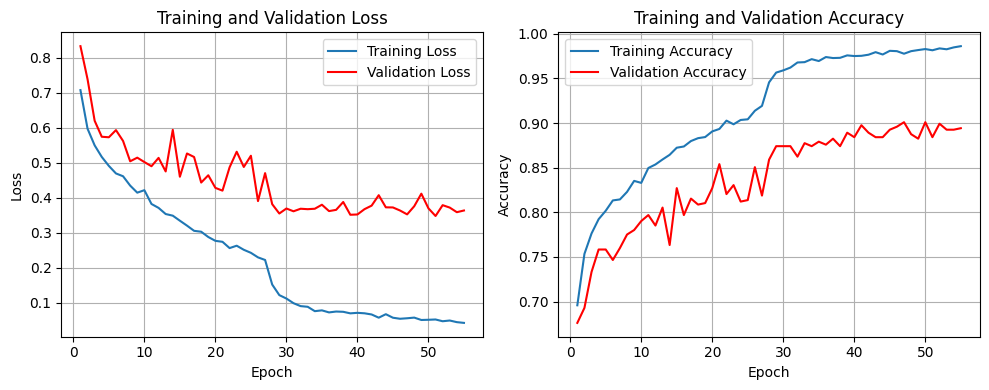

In [44]:
plt.figure(figsize=(10, 4))

# Loss
plt.subplot(1, 2, 1)

plt.plot(
    history_class_specific["epoch"],
    history_class_specific["train_loss"],
    label="Training Loss"
)

plt.plot(
    history_class_specific["epoch"],
    history_class_specific["val_loss"],
    label="Validation Loss",
    color="red"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)


# Accuracy
plt.subplot(1, 2, 2)

plt.plot(
    history_class_specific["epoch"],
    history_class_specific["train_acc"],
    label="Training Accuracy"
)

plt.plot(
    history_class_specific["epoch"],
    history_class_specific["val_acc"],
    label="Validation Accuracy",
    color="red"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()